# Best Subset Selection

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold


RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

## 1. Load the Dataset and Inspect

The dataset that will be used is `load_diabetes` dataset from sklearn library. This dataset has 10 features.

In [43]:
diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

df = pd.DataFrame(X, columns=load_diabetes().feature_names)
df['target'] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### 1.1 Dataset Shape

In this dataset we have:
- 442 samples.
- 11 attributes (10 of are features and 1 is target)

In [44]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (442, 11)


### 1.2 Dataset Info

- No missing values.
- No qualitative attribute meaning no need for encoders.
- The need of a scaler is not yet been justfied.

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


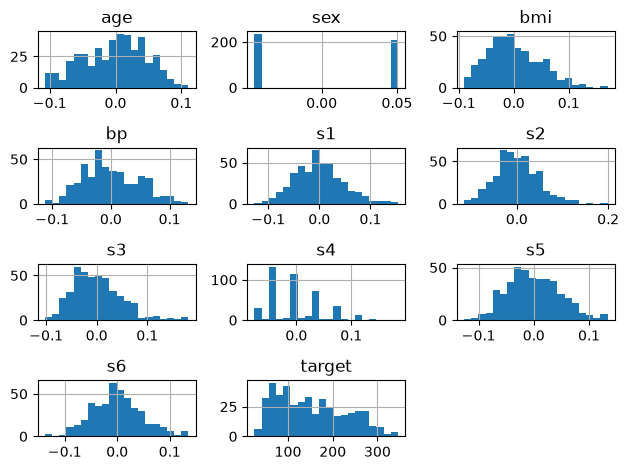

In [46]:
df.hist(bins=20)
plt.tight_layout()
plt.show();

In [47]:
df[df['sex'] > 0].head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.05068,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
2,0.085299,0.05068,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
6,-0.045472,0.05068,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.05068,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.05068,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0


## 2. Split dataset

`train_test_split()` will be used to split the dataset 

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED
)

## 3. Implement Best Subset Selection Algorithm

### 3.1 Test itertools.conbinations First

This can be used to generate conbinations of an iterable.

In [49]:
items = ['A', 'B', 'C']
numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9]

iterator = combinations(numbers, 2)

# print(list(iterator))
# for subset in list(iterator):
#     print(subset)

### 3.2 Implement Best Subset Selection Algorithm

- **RSS**: an error metric that measures the total squared difference between the actual data values and the values predicted by a regression model.

In [73]:
results = []
for k in range(1, X_train.shape[1] + 1):
    rss = []
    for subset in combinations(X_train.columns, k):

        model = LinearRegression()
        model.fit(X_train[list(subset)], y_train)
        y_pred = model.predict(X_train[list(subset)])

        subset_rss = ((y_train - y_pred) ** 2).sum()

        rss.append((subset_rss, subset))

    results.append(min(rss, key=lambda x: x[0]))

In [74]:
for i, result in enumerate(results):
    print(f"({i}) RSS: {result[0]}, {result[1]}")

(0) RSS: 1360501.7661827644, ('bmi',)
(1) RSS: 1161834.7519467813, ('bmi', 's5')
(2) RSS: 1108649.5035964558, ('bmi', 'bp', 's5')
(3) RSS: 1074425.5272317054, ('bmi', 'bp', 's1', 's5')
(4) RSS: 1040983.5653990463, ('sex', 'bmi', 'bp', 's3', 's5')
(5) RSS: 1022172.2639890872, ('sex', 'bmi', 'bp', 's1', 's2', 's5')
(6) RSS: 1016695.1037401557, ('sex', 'bmi', 'bp', 's1', 's2', 's4', 's5')
(7) RSS: 1015027.3246336153, ('sex', 'bmi', 'bp', 's1', 's2', 's4', 's5', 's6')
(8) RSS: 1013490.0819656126, ('sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6')
(9) RSS: 1012598.0451009589, ('age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6')


### 3.3 Plot RSS Values

10
range(1, 11)


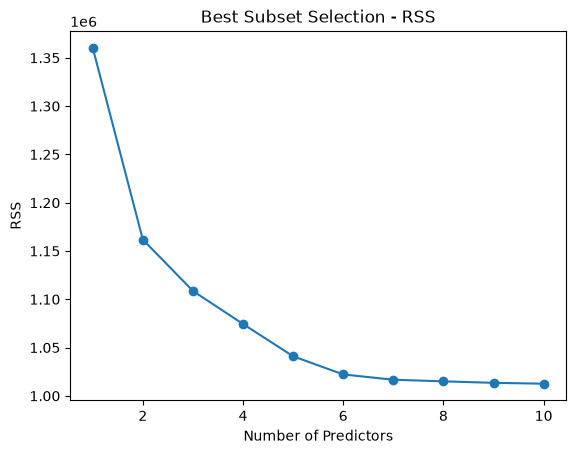

In [70]:
rss_values = [x[0] for x in results]
print(len(rss_values))
model_sizes = range(1, len(results) + 1)
print(model_sizes)

plt.plot(model_sizes, rss_values, marker="o")
plt.xlabel("Number of Predictors")
plt.ylabel("RSS")
plt.title("Best Subset Selection - RSS")
plt.show();

#### Notes

RSS continuously decreases because increasing model size gives the model greater flexibility. Therefore training RSS alone cannot determine the optimal model size.

This was also pointed out in textbook "An Introduction to Statistical Learning"

### 3.4 Adjusted R-Squared

**R-squared** is a statistical measure that represent the goodness of fit of a regression model.

- The value of R-square lies between 0 to 1.
- Where we get R-square equals 1 when the model perfectly fits the data.
- 0 when the model does not predict any variability in the model.

#### 3.4.1 How is R-Squared Calculate

1. calculate the mean of the target/dependent variable y_mean.
2. Calculate the total sum of squares by subtracting each observation y_i from y_mean, then squaring it and summing these square differences across all the values.
3. We calculate the sum of squares. It explains unaccounted variability in the dependent y after predicting these values from an independent variable in the model.

In [71]:
def r_squared(y, y_pred):
    # Calculate Residual sum of squares
    ss_res = np.sum((y - y_pred) ** 2)

    # calculate total sum of squares
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r_squared_val = 1 - (ss_res / ss_tot)

    return r_squared_val

In [81]:
def adjusted_r_squared(y, y_pred, k):
    n = y.shape[0]
    return 1 - ((1 - r_squared(y, y_pred)) * (n - 1)) / (n - k - 1)

In [83]:
results = []
for k in range(1, X_train.shape[1] + 1):
    subset_results = []
    for subset in combinations(X_train.columns, k):

        model = LinearRegression()
        model.fit(X_train[list(subset)], y_train)
        y_pred = model.predict(X_train[list(subset)])

        subset_rss = ((y_train - y_pred) ** 2).sum()
        adj_r2 = adjusted_r_squared(
            y_train,
            y_pred,
            k=len(subset)
        )

        subset_results.append((adj_r2, subset_rss, subset))

    results.append(max(subset_results, key=lambda x: x[0]))

In [84]:
for k, result in enumerate(results, start=1):
    adj_r2, rss, subset = result

    print(
        f"k={k}, "
        f"Adjusted R²={adj_r2:.4f}, "
        f"RSS={rss:.2f}, "
        f"Features={subset}"
    )

k=1, Adjusted R²=0.3639, RSS=1360501.77, Features=('bmi',)
k=2, Adjusted R²=0.4552, RSS=1161834.75, Features=('bmi', 's5')
k=3, Adjusted R²=0.4787, RSS=1108649.50, Features=('bmi', 'bp', 's5')
k=4, Adjusted R²=0.4933, RSS=1074425.53, Features=('bmi', 'bp', 's1', 's5')
k=5, Adjusted R²=0.5077, RSS=1040983.57, Features=('sex', 'bmi', 'bp', 's3', 's5')
k=6, Adjusted R²=0.5152, RSS=1022172.26, Features=('sex', 'bmi', 'bp', 's1', 's2', 's5')
k=7, Adjusted R²=0.5164, RSS=1016695.10, Features=('sex', 'bmi', 'bp', 's1', 's2', 's4', 's5')
k=8, Adjusted R²=0.5158, RSS=1015027.32, Features=('sex', 'bmi', 'bp', 's1', 's2', 's4', 's5', 's6')
k=9, Adjusted R²=0.5151, RSS=1013490.08, Features=('sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6')
k=10, Adjusted R²=0.5141, RSS=1012598.05, Features=('age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6')


#### Plot Adjusted R-Squared

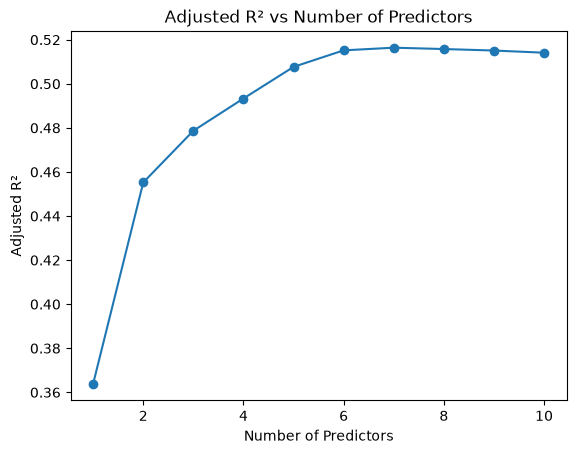

In [85]:
adj_r2_values = [result[0] for result in results]

plt.plot(
    range(1, len(results) + 1),
    adj_r2_values,
    marker="o"
)

plt.xlabel("Number of Predictors")
plt.ylabel("Adjusted R²")
plt.title("Adjusted R² vs Number of Predictors")

plt.show()

### 3.5 Bayseeian Information Criterion (BIC)

The Bayesian Information Criterion (BIC) is a statistical measure used for model selection from a finite set of models. BIC helps in identifying the model that best explains the data while balancing model complexity and goodness of fit.

$$
BIC = -2ln(L) + kln(n)
$$

for linear regression, this formula simplifies:

$$
BIC = nln(\frac{RSS}{n}) + kln(n)
$$

- $L$ is the likelihood of the model given the data.
- $k$ is the number of parameters in the model.
- $n$ is the number of data points.

The first term, $-2ln(L)$, assesses the model's fit to the data, while the second term, $kln(n)$, penalize the model based on its complexity.

The model with the lowest BIC is favored because it offers the optimal balance between fitting the data well and maintaining simplicity.

#### 3.5.1 Advantages of Bayesian Information Criterion (BIC)

- **Simplicity**: BIC is easy to compute and interpret.
- **Penalization for Complexity**: The penalty term helps prevent overfitting by favoring simpler models.
- **Model Comparison**: BIC allows for straightforward comparison among multiple models.

#### 3.5.2 Limitations of Bayesian Information Criterion (BIC)

- **Assumption of Large Sample Size**: BIC assumes a large sample size, and its accuracy may diminish with smaller datasets.
- **Model Assumptions**: BIC relies on the assumption that the true model is among the set of candidate models, which may not always be the case.
- **Overemphasis on Simplicity**: The heavy penalty for the number of parameters might lead to the selection of overly simplistic models.

In [86]:
def bic(y, y_pred, num_predictors):
    n = len(y)

    rss = np.sum((y - y_pred) ** 2)

    # predictors + intercept
    k = num_predictors + 1

    return n * np.log(rss / n) + k * np.log(n)

In [87]:
results = []
for k in range(1, X_train.shape[1] + 1):
    subset_results = []
    for subset in combinations(X_train.columns, k):

        model = LinearRegression()
        model.fit(X_train[list(subset)], y_train)
        y_pred = model.predict(X_train[list(subset)])

        subset_rss = ((y_train - y_pred) ** 2).sum()
        adj_r2 = adjusted_r_squared(
            y_train,
            y_pred,
            k=len(subset)
        )

        bic_value = bic(
            y_train,
            y_pred,
            k
        )

        subset_results.append((adj_r2, bic_value, subset_rss, subset))

    results.append(min(subset_results, key=lambda x: x[1]))

In [88]:
for k, result in enumerate(results, start=1):
    adj_r2, bic_value, rss, subset = result

    print(
        f"k={k}, "
        f"Adjusted R²={adj_r2:.4f}, "
        f"BIC={bic_value:.4f}"
        f"RSS={rss:.2f}, "
        f"Features={subset}"
    )

k=1, Adjusted R²=0.3639, BIC=2926.4173RSS=1360501.77, Features=('bmi',)
k=2, Adjusted R²=0.4552, BIC=2876.5616RSS=1161834.75, Features=('bmi', 's5')
k=3, Adjusted R²=0.4787, BIC=2865.8872RSS=1108649.50, Features=('bmi', 'bp', 's5')
k=4, Adjusted R²=0.4933, BIC=2860.6848RSS=1074425.53, Features=('bmi', 'bp', 's1', 's5')
k=5, Adjusted R²=0.5077, BIC=2855.3894RSS=1040983.57, Features=('sex', 'bmi', 'bp', 's3', 's5')
k=6, Adjusted R²=0.5152, BIC=2854.8186RSS=1022172.26, Features=('sex', 'bmi', 'bp', 's1', 's2', 's5')
k=7, Adjusted R²=0.5164, BIC=2858.7885RSS=1016695.10, Features=('sex', 'bmi', 'bp', 's1', 's2', 's4', 's5')
k=8, Adjusted R²=0.5158, BIC=2864.0754RSS=1015027.32, Features=('sex', 'bmi', 'bp', 's1', 's2', 's4', 's5', 's6')
k=9, Adjusted R²=0.5151, BIC=2869.4068RSS=1013490.08, Features=('sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6')
k=10, Adjusted R²=0.5141, BIC=2874.9625RSS=1012598.05, Features=('age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6')


#### Notes
Training RSS continually decreased as the number of predictors increased and therefore selected the full 10-predictor model. Adjusted \(R^2\) reached its maximum at 7 predictors, while BIC reached its minimum at 6 predictors. This demonstrates how complexity-adjusted criteria can prefer smaller models even when additional predictors improve training fit.

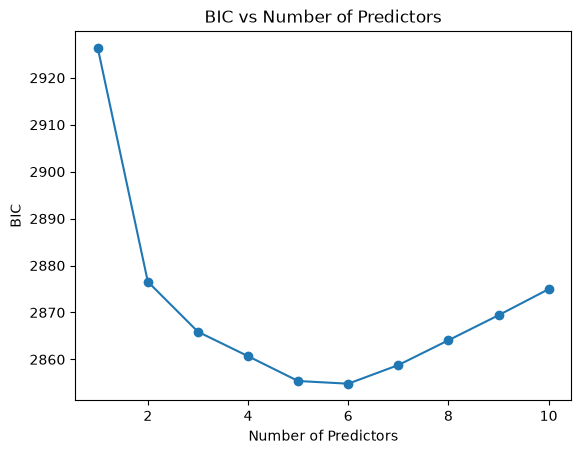

In [89]:
bic_values = [result[1] for result in results]

plt.plot(
    range(1, len(results) + 1),
    bic_values,
    marker="o"
)

plt.xlabel("Number of Predictors")
plt.ylabel("BIC")
plt.title("BIC vs Number of Predictors")
plt.show()

In [90]:
best_bic = min(results, key=lambda x: x[1])

print(best_bic)

(np.float64(0.515192043489128), np.float64(2854.8185810314535), np.float64(1022172.2639890872), ('sex', 'bmi', 'bp', 's1', 's2', 's5'))


In [97]:
# Test on feature model selected by BIC

features = ('sex', 'bmi', 'bp', 's1', 's2', 's5')

model_0 = LinearRegression()

model_0.fit(X_train[list(features)], y_train)

y_test_pred_bic = model_0.predict(X_test[list(features)])

test_mse_bic = mean_squared_error(y_test, y_test_pred_bic)
test_r2_bic = r2_score(y_test, y_test_pred_bic)

print("Test MSE BIC:", test_mse_bic)
print("Test RMSE BIC:", np.sqrt(test_mse_bic))
print("Test R² BIC:", test_r2_bic)

Test MSE BIC: 2846.290524213761
Test RMSE BIC: 53.35063752396742
Test R² BIC: 0.46277670793202985


In [98]:
# Test on feature model selected by R-Squared

features = ('sex', 'bmi', 'bp', 's1', 's2', 's4', 's5')

model_1 = LinearRegression()

model_1.fit(X_train[list(features)], y_train)

y_test_pred_r2 = model_1.predict(X_test[list(features)])

test_mse_r2 = mean_squared_error(y_test, y_test_pred_r2)
test_r2_r2 = r2_score(y_test, y_test_pred_r2)

print("Test MSE R2:", test_mse_r2)
print("Test RMSE R2:", np.sqrt(test_mse_r2))
print("Test R²:", test_r2_r2)

Test MSE R2: 2870.245584666389
Test RMSE R2: 53.574672977689644
Test R²: 0.4582553084724287


In [99]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Test MSE Full:", mean_squared_error(y_test, y_pred))
print("Test RMSE Full:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test R² Full:", r2_score(y_test, y_pred))

Test MSE Full: 2900.1936284934804
Test RMSE Full: 53.85344583676592
Test R² Full: 0.4526027629719197


In [103]:
def best_subset(X, y, k):
    best_rss = np.inf
    best_features = None

    for subset in combinations(X.columns, k):

        model = LinearRegression()
        model.fit(X[list(subset)], y)

        y_pred = model.predict(X[list(subset)])

        rss = np.sum((y - y_pred) ** 2)

        if rss < best_rss:
            best_rss = rss
            best_features = subset

    return best_features

## Cross-Validation

In [102]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

In [104]:
cv_results = []

for k in range(1, X_train.shape[1] + 1):
    fold_mse = []

    for train_idx, val_idx in kf.split(X_train):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        features = best_subset(
            X_fold_train,
            y_fold_train,
            k
        )

        model = LinearRegression()

        model.fit(
            X_fold_train[list(features)],
            y_fold_train
        )

        # Evaluate on validation fold
        y_val_pred = model.predict(
            X_fold_val[list(features)]
        )

        mse = mean_squared_error(
            y_fold_val,
            y_val_pred
        )

        fold_mse.append(mse)

    mean_cv_mse = np.mean(fold_mse)

    cv_results.append((k, mean_cv_mse))


In [105]:
for k, mse in cv_results:
    print(f"k={k}, CV MSE={mse:.2f}")

k=1, CV MSE=3909.15
k=2, CV MSE=3358.96
k=3, CV MSE=3215.32
k=4, CV MSE=3186.96
k=5, CV MSE=3098.36
k=6, CV MSE=3037.99
k=7, CV MSE=3078.27
k=8, CV MSE=3064.77
k=9, CV MSE=3072.79
k=10, CV MSE=3074.14


In [106]:
best_k = min(cv_results, key=lambda x: x[1])

print(best_k)

(6, np.float64(3037.9891688279117))


In [107]:
final_features = best_subset(
    X_train,
    y_train,
    k=6
)

print(final_features)

('sex', 'bmi', 'bp', 's1', 's2', 's5')


In [108]:
final_model = LinearRegression()

final_model.fit(
    X_train[list(final_features)],
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-215.27, 557.31, 350.18,-851.52, 591.09, 803.12]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['sex','bmi','bp','s1','s2','s5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [109]:
y_test_pred = final_model.predict(
    X_test[list(final_features)]
)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("Final features:", final_features)
print("Test MSE:", test_mse)
print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

Final features: ('sex', 'bmi', 'bp', 's1', 's2', 's5')
Test MSE: 2846.290524213761
Test RMSE: 53.35063752396742
Test R²: 0.46277670793202985
